# Digit recognizer
Programa creado para clasificar imágenes 28x28 de dígitos según su etiqueta 0-9 con algoritmos de Inteligencia Artificial

### IDEAS
- Darle pesos (con ML?) a cada imagen del dataset en la creación de los números ideales, ya que no todas son igual de representativas
- Probar con redes neuronales (NNs)

# NOTAS
* Tambíen se pueden invertir los errores multiplicando por -1
* Cambiar métrica de evaluación para clasificación multiclase

# Análisis del dataset

In [1]:
"""
IMPORTANTE:
En Github no se encuentran los archivos de 'train.csv' y 'test.csv' (pesan mucho)
Sin embargo, si que tenemos una carpeta ZIP con esos archivos. Para ejecutar el código,
se deben extraer primero (dentro de la carpeta)
"""

import pandas as pd

train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

In [2]:
# train.describe()

In [3]:
# Para reducir los tiempos de espera, se reduce el dataframe de train
train = train[:5_000]

In [4]:
train_nulls = train.isnull().sum().values
test_nulls = test.isnull().sum().values

print(f"Número de valores nulos en train: {train_nulls.sum()}")
print(f"Número de valores nulos en test: {test_nulls.sum()}")

Número de valores nulos en train: 0
Número de valores nulos en test: 0


Vemos en la documentación (https://www.kaggle.com/competitions/digit-recognizer) que las imágenes tienen 28x28 píxeles en escala de grises, con valores entre 0-255

Primero, vamos a normalizar las columnas para que tengan valores entre 0 y 1. Luego, crearçmos una función que muestre por pantalla una imagen específica del dataset para visualizarla mejor

In [5]:
# Dividimos cada columna entre 255
for col in train.columns:
    if col != "label":
        train[col] /= 255

for col in test.columns:
    if col != "label":
        test[col] /= 255

# Comprobamos que haya funcionado
# train.describe()

In [6]:
# Como parece que vamos a usar mucho este código, añado una función que convierta una fila de los datos en un array 2D
def crearMatriz(df, i):
    img = df.iloc[i]

    # Quitamos la columna 'label' si existe
    title = f"Image #{i}"
    label = None
    if "label" in img.index:
        title += f" (Number {int(img["label"])})"
        label = int(img["label"])
        # Convertimos el data series de pandas a un array de numpy
        # y eliminamos el valor "label" (ubicado en la primera posición)
        img = img.values[1:]
    else:
        img = img.values
        

    # Ahora, transformamos el array en un array 2D, 28x28
    img = img.reshape((28, 28))
    
    return img, label, title

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def mostrarImagenDF(df, i):
    """
    Mostrar una imágen a partir de una columna del DataFrame
    df: dataframe
    i: integer
    """
    img, label, title = crearMatriz(df, i)

    plt.imshow(img, cmap="gray", vmin=0, vmax=1)
    plt.title(label=title)
    plt.show()


def mostrarMatrizImagen(img, title=""):
    """
    Mostrar una imágen a partir de una matriz de píxeles
    img: Matriz de valores [0, 1]
    title: Texto para mostrar 
    """

    plt.imshow(img, cmap="gray", vmin=0, vmax=1)
    plt.title(label=title)
    plt.show()



Creamos una función para visualizar todos los datos de un dataset [simplemente para probar que números aparecen]

In [8]:
from IPython.display import clear_output


def mostrarImgsDataframe(df, inicio, fin):
    # Activa modo interactivo
    plt.ion()

    for i in range(inicio, fin):
        # Usamos el código anterior para dibujar la matriz 2D
        img, label, title = crearMatriz(df, i)

        plt.imshow(img, cmap="gray", vmin=0, vmax=1)
        plt.title(label=title)
        plt.axis("off")

        # Refrescamos la ventana y esperamos N segundos
        plt.pause(0.02)

        # Borramos el output anterior
        clear_output(wait=True)
        plt.show()


# mostrarImgsDataframe(train, 0, 20)

# Creación de las matrices de 'números ideales'

Con el fin de evaluar a que label corresponde cada matriz, vamos a comprobar a que 'número ideal' se parece más dicha matriz. Estos 'números ideales' serán calculados como la media de los números de ese 'label'; es decir, se superponen los números uno encima de otro y se calcula cual es el 'número promedio' o 'número ideal'

In [9]:
# Función para mostrar las imágenes de esos números ideales. La usaremos más adelante
def mostrarNumsIdeales(nums, figsize=(7, 7)):
    """
    nums: list de números ideales
    """

    fig, axs = plt.subplots(nrows=2, ncols=5, figsize=figsize)
    # Convertimos la matriz 2D de sublots en una lista 1D
    axs = axs.flatten()

    for i in range(len(nums)):
        img = nums[i]
        title = f"Número {i}"

        axs[i].set_title(title)
        axs[i].imshow(img, cmap="gray", vmin=0, vmax=1)
        axs[i].axis("off")

    plt.show()

In [10]:
# --- Para el conjunto 'train', se crea un número ideal para cada label 0-9 ---

# Creamos unas matrices para guardar la suma/superposición de matrices
nums_ideales = []
for i in range(10):
    matriz = np.zeros((28, 28))
    nums_ideales.append(matriz)


for i in range(len(train)):
    vector_img, label, _ = crearMatriz(train, i)

    # Sumamos los valores de cada pixel a su matriz correspondiente
    nums_ideales[label] += vector_img

media_total_pixeles = 0

# Ahora, necesitamos normalizar los valores entre 0 y 1
for i in range(len(nums_ideales)):
    valor_maximo = nums_ideales[i].max()
    if valor_maximo == 0:
        raise ValueError("La matriz está vacía")

    # El valor máximo tendrá un valor de (1 / valor_maximo) * valor_maximo = 1
    # Y el mínimo de (1 / valor_maximo) * 0 = 0
    nums_ideales[i] = np.multiply(1 / valor_maximo, nums_ideales[i])

    # -- Suavizamos la nube borrosa incluyendo solo los datos por encima de un valor límite --
    limite = 0.5
    # Coeficiente de suavizado (0 elimina el píxel, 1 no hace ningún cambio)
    coef_suavizado = 0.75

    # for x in range(nums_ideales[i].shape[0]):
    #     for y in range(nums_ideales[i].shape[1]):
    #         # Si es menor que el límite, suavizamos su valor
    #         if nums_ideales[i][x][y] < limite:
    #             nums_ideales[i][x][y] *= coef_suavizado
    media_total_pixeles += nums_ideales[i].sum()

# media_total_pixeles /= len(nums_ideales)
# print("media", media_total_pixeles)
# # -- Queremos que todas las matrices tengan la misma cantidad de pixeles blancos --
# # La suma de todos los pixeles debe ser 'media_total_pixeles', por lo que debemos dividir cada
# # pixel por la diferencia (sum() / media_total_pixeles)
# for i in range(len(nums_ideales)):
#     suma = nums_ideales[i].sum()
#     factor_mult = media_total_pixeles / suma
#     nums_ideales[i] *= factor_mult

# # Comprobamos
# for i in range(len(nums_ideales)):
#     suma = nums_ideales[i].sum()
#     print(i, suma)

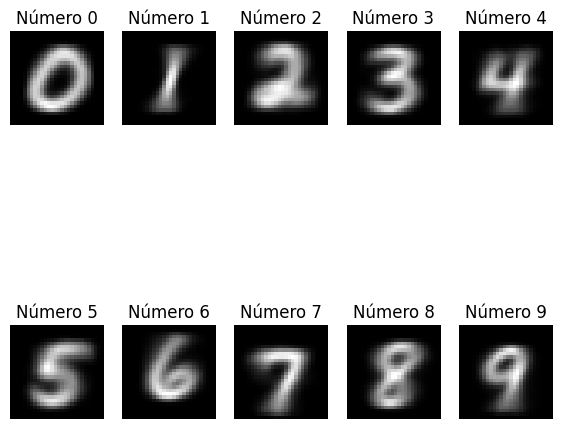

In [11]:
# Podemos visualizar el resultado usando las funciones anteriores
mostrarNumsIdeales(nums_ideales)

# Comparación de los datos y los números ideales

Ahora, podemos ver si somos capaces de identificar una imagen por su similitud a un número ideal

Para ello, compararemos esa imagen con cada número ideal y elegimos la que sea más parecida (la que tenga menor error)

### Método 1
Diferencia entre matrices con pixeles con valores contínuos [0, 1]

In [12]:
def predict(df, idx, mostrarErrores=True):
    img, label, title = crearMatriz(df, idx)

    # Guardamos la matriz de error de cada número ideal
    matrices_resta = []
    errores = []

    """
    * Para el caso discreto en el que un pixel pertenece a {0, 1}
    Llamamos p al valor del pixel y P al valor esperado (valor del píxel ideal)
    Queremos minimizar, así que el número que estamos buscando tendrá el menor valor
        - If (p == 0 and P == 0) or (p == 1 and P == 1):
    Es lo que buscamos, no sumamos nada
        - If (p == 0 and P == 1) or (p == 1 and P == 0):
    Añadimos 1 a la suma; ese pixel no se corresponde al ideal
    
    * Para el caso continuo en el que un pixel pertenece al intervalo [0, 1]
        - If (p == 0 and P == 0) or (p == 1 and P == 1):
    Es lo que buscamos, no sumamos nada
        - Else:
    # Tanto si el pixel debería ser más claro o más oscuro, añadimos ese error/diferencia
    # NOTA: Quizá se puede penalizar más a los pixeles que deberían ser oscuros y son claros (o viceversa)
    Añadimos abs(p - P) a la suma; ese pixel no se corresponde al ideal
    
    --> Al final, se deduce que se quiere calcular abs(p - P) para cada pixel, por lo que se puede operar
    la matriz entera usando métodos de Numpy para conseguir el mismo resultado
    """
    for i in range(len(nums_ideales)):

        matriz_differencia = np.abs(np.subtract(nums_ideales[i], img))
        err = np.sum(matriz_differencia)
        err = float(round(err, 3))  # Para mejorar la lectura de los datos

        matrices_resta.append(matriz_differencia)
        errores.append(err)

    # Normalizamos los errores para conseguir la probabilidad
    # El menor error tendrá la probabilidad mayor (de manera proporcional)
    # Primero, "invertimos" los valores para que el menor error tenga el mayor valor
    max_err = np.max(errores)
    for e in range(len(errores)):
        err = max_err - errores[e]
        errores[e] = float(round(err, 5))

    # Después calculamos la probabilidad normalizada de elegir cada número ideal
    vector_probabilidades = []
    for i in range(len(errores)):
        probabilidad = float(errores[i] / np.sum(errores))
        vector_probabilidades.append(round(probabilidad, 5))
    """
    Errores (abs):                [158.783, 131.972, 150.416, 153.856, 94.291, 153.081, 129.619, 132.346, 145.306, 116.825]
    Errores "invertidos":         [0.0, 26.811, 8.367, 4.927, 64.492, 5.702, 29.164, 26.437, 13.477, 41.958]
    Probabilidades normalizadas:  [0.0, 0.12113, 0.0378, 0.02226, 0.29138, 0.02576, 0.13176, 0.11944, 0.06089, 0.18957]
    """

    prediccion = vector_probabilidades.index(max(vector_probabilidades))


    if mostrarErrores:
        print(f"Errores:\n{errores}\tMínimo err: {min(errores)}")
        print(f"Probabilidades:\n{vector_probabilidades} ----> {prediccion}")
        print("sumatorio probs.", np.sum(vector_probabilidades))
        mostrarNumsIdeales(matrices_resta, figsize=(7, 5))

    # Devolvemos el valor del mínimo error; es decir, el índice de la matriz correspondiente
    return prediccion

In [13]:
# Probamos a predecir todos los números de 'train'          !!!!!!!!!!!!!!!!!!!!!!!!! NO estamos probando en 'test' !!!!!!!!!
# Guardamos el total de aciertos para cada número
aciertos = [0] * 10
fallos = [0] * 10

for i in range(len(train)):
    prediccion = predict(train, i, mostrarErrores=False)
    target = int(train.iloc[i]["label"])

    # Sumamos uno si acierta
    if prediccion == target:
        aciertos[target] += 1
    else:
        fallos[target] += 1


In [14]:
def calcular_resultados(aciertos, fallos):
    print("Aciertos:")
    print(aciertos)
    print("Fallos:")
    print(fallos)

    print("\nPorcentajes de acierto para cada clase ideal:")
    porcentajes = []
    for i in range(10):
        porcentaje = aciertos[i] / (aciertos[i] + fallos[i])
        porcentajes.append(round(porcentaje, 5))
    print(porcentajes)

    media = np.mean(porcentajes)
    print("\nPorcentaje medio de acierto: ", media)

    # --- Lo visualizamos todo como un DataFrame ---
    resultados = {
        "Aciertos": aciertos + [np.mean(aciertos)],
        "Fallos": fallos + [np.mean(fallos)],
        "Porcentaje": porcentajes + [media],
        "Número": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, "MEDIA"],
    }
    df_resultados = pd.DataFrame(resultados)
    # El índice para cada elemento pasa de ser 0, 1, 2... a ser los elementos de 'Número" (que en este caso son iguales)
    df_resultados.set_index("Número", inplace=True)
    
    return df_resultados

df_resultados1 = calcular_resultados(aciertos, fallos)
df_resultados1

Aciertos:
[386, 556, 204, 231, 290, 103, 368, 348, 193, 327]
Fallos:
[108, 2, 341, 249, 187, 366, 148, 158, 284, 151]

Porcentajes de acierto para cada clase ideal:
[0.78138, 0.99642, 0.37431, 0.48125, 0.60797, 0.21962, 0.71318, 0.68775, 0.40461, 0.6841]

Porcentaje medio de acierto:  0.595059


,Aciertos,Fallos,Porcentaje
Número,,,
0,386.0,108.0,0.781380
1,556.0,2.0,0.996420
2,204.0,341.0,0.374310
3,231.0,249.0,0.481250
4,290.0,187.0,0.607970
5,103.0,366.0,0.219620
6,368.0,148.0,0.713180
7,348.0,158.0,0.687750
8,193.0,284.0,0.404610


### Método 2
Diferencia entre matrices con pixeles de valores discretos {0, 1}

In [15]:
def predict2(df, idx, mostrarErrores=True):
    img, label, title = crearMatriz(df, idx)

    # Guardamos la matriz de error de cada número ideal
    matrices_resta = []
    errores = []

    """
    Mismo procedimiento (valor absoluto de la resta), pero primero "binarizamos" la matriz 'img'
    """
    # Valores entre 0 y 1
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            img[i][j] = round(img[i][j])

    for i in range(len(nums_ideales)):

        matriz_differencia = np.abs(np.subtract(nums_ideales[i], img))
        err = np.sum(matriz_differencia)
        err = float(round(err, 3))  # Para mejorar la lectura de los datos

        matrices_resta.append(matriz_differencia)
        errores.append(err)

    # Normalizamos los errores para conseguir la probabilidad
    # El menor error tendrá la probabilidad mayor (de manera proporcional)
    # Primero, "invertimos" los valores para que el menor error tenga el mayor valor
    max_err = np.max(errores)
    for e in range(len(errores)):
        err = max_err - errores[e]
        errores[e] = float(round(err, 5))

    # Después calculamos la probabilidad normalizada de elegir cada número ideal
    vector_probabilidades = []
    for i in range(len(errores)):
        probabilidad = float(errores[i] / np.sum(errores))
        vector_probabilidades.append(round(probabilidad, 5))

    prediccion = vector_probabilidades.index(max(vector_probabilidades))

    if mostrarErrores:
        print(f"Errores:\n{errores}\tMínimo err: {min(errores)}")
        print(f"Probabilidades:\n{vector_probabilidades} ----> {prediccion}")
        print("sumatorio probs.", np.sum(vector_probabilidades))
        mostrarNumsIdeales(matrices_resta, figsize=(7, 5))

    # Devolvemos el valor del mínimo error; es decir, el índice de la matriz correspondiente
    return prediccion

In [16]:
# Probamos a predecir todos los números de 'train'          !!!!!!!!!!!!!!!!!!!!!!!!! NO estamos probando en 'test' !!!!!!!!!
# Guardamos el total de aciertos para cada número
aciertos = [0] * 10
fallos = [0] * 10

for i in range(len(train)):
    prediccion = predict2(train, i, mostrarErrores=False)
    target = int(train.iloc[i]["label"])

    # Sumamos uno si acierta
    if prediccion == target:
        aciertos[target] += 1
    else:
        fallos[target] += 1

In [17]:
df_resultados2 = calcular_resultados(aciertos, fallos)
df_resultados2

Aciertos:
[359, 556, 167, 187, 253, 72, 327, 332, 145, 286]
Fallos:
[135, 2, 378, 293, 224, 397, 189, 174, 332, 192]

Porcentajes de acierto para cada clase ideal:
[0.72672, 0.99642, 0.30642, 0.38958, 0.5304, 0.15352, 0.63372, 0.65613, 0.30398, 0.59833]

Porcentaje medio de acierto:  0.5295219999999999


,Aciertos,Fallos,Porcentaje
Número,,,
0,359.0,135.0,0.726720
1,556.0,2.0,0.996420
2,167.0,378.0,0.306420
3,187.0,293.0,0.389580
4,253.0,224.0,0.530400
5,72.0,397.0,0.153520
6,327.0,189.0,0.633720
7,332.0,174.0,0.656130
8,145.0,332.0,0.303980


### Método 2B
Binarizamos los números ideales y el número a predecir

In [18]:
# --- Binarizamos cada número ideal ---
nums_ideales2b = nums_ideales.copy()

for n in range(len(nums_ideales2b)):
    for i in range(nums_ideales2b[n].shape[0]):
        for j in range(nums_ideales2b[n].shape[1]):
            nums_ideales2b[n][i][j] = round(nums_ideales2b[n][i][j])

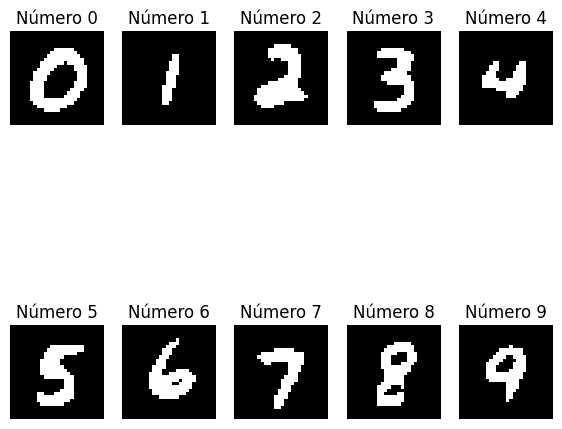

In [19]:
mostrarNumsIdeales(nums_ideales2b)

In [20]:
def predict2b(df, idx, mostrarErrores=True):
    img, label, title = crearMatriz(df, idx)

    # Guardamos la matriz de error de cada número ideal
    matrices_resta = []
    errores = []

    """
    Mismo procedimiento (valor absoluto de la resta), pero primero "binarizamos" la matriz 'img'
    """
    # Valores entre 0 y 1
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            img[i][j] = round(img[i][j])

    for i in range(len(nums_ideales2b)):

        matriz_differencia = np.abs(np.subtract(nums_ideales2b[i], img))
        err = np.sum(matriz_differencia)
        err = float(round(err, 3))  # Para mejorar la lectura de los datos

        matrices_resta.append(matriz_differencia)
        errores.append(err)

    # Normalizamos los errores para conseguir la probabilidad
    # El menor error tendrá la probabilidad mayor (de manera proporcional)
    # Primero, "invertimos" los valores para que el menor error tenga el mayor valor
    max_err = np.max(errores)
    for e in range(len(errores)):
        err = max_err - errores[e]
        errores[e] = float(round(err, 5))

    # Después calculamos la probabilidad normalizada de elegir cada número ideal
    vector_probabilidades = []
    for i in range(len(errores)):
        probabilidad = float(errores[i] / np.sum(errores))
        vector_probabilidades.append(round(probabilidad, 5))

    prediccion = vector_probabilidades.index(max(vector_probabilidades))

    if mostrarErrores:
        print(f"Errores:\n{errores}\tMínimo err: {min(errores)}")
        print(f"Probabilidades:\n{vector_probabilidades} ----> {prediccion}")
        print("sumatorio probs.", np.sum(vector_probabilidades))
        mostrarNumsIdeales(matrices_resta, figsize=(7, 5))

    # Devolvemos el valor del mínimo error; es decir, el índice de la matriz correspondiente
    return prediccion

In [21]:
# Probamos a predecir todos los números de 'train'          !!!!!!!!!!!!!!!!!!!!!!!!! NO estamos probando en 'test' !!!!!!!!!
# Guardamos el total de aciertos para cada número
aciertos = [0] * 10
fallos = [0] * 10

for i in range(len(train)):
    prediccion = predict2b(train, i, mostrarErrores=False)
    target = int(train.iloc[i]["label"])

    # Sumamos uno si acierta
    if prediccion == target:
        aciertos[target] += 1
    else:
        fallos[target] += 1

In [22]:
df_resultados2b = calcular_resultados(aciertos, fallos)
df_resultados2b

Aciertos:
[377, 550, 262, 320, 345, 204, 358, 381, 265, 261]
Fallos:
[117, 8, 283, 160, 132, 265, 158, 125, 212, 217]

Porcentajes de acierto para cada clase ideal:
[0.76316, 0.98566, 0.48073, 0.66667, 0.72327, 0.43497, 0.6938, 0.75296, 0.55556, 0.54603]

Porcentaje medio de acierto:  0.6602809999999999


,Aciertos,Fallos,Porcentaje
Número,,,
0,377.0,117.0,0.763160
1,550.0,8.0,0.985660
2,262.0,283.0,0.480730
3,320.0,160.0,0.666670
4,345.0,132.0,0.723270
5,204.0,265.0,0.434970
6,358.0,158.0,0.693800
7,381.0,125.0,0.752960
8,265.0,212.0,0.555560


### Método 3
Distancia euclídea entre vectores
Transformamos cada matriz ideal 28x28 y cada número a predecir en un vector (0, 784) y calculamos su distancia euclídea

In [23]:
vectores_ideales = []
for num in nums_ideales:
    vector = num.reshape((1, 784))
    vectores_ideales.append(vector)


def predict3(df, idx, mostrar_distancias=False):
    vector_img, label, title = crearMatriz(df, idx)

    # Vectorizamos la imagen
    vector_img = vector_img.reshape((1, 784))

    distancias = []
    # Calculamos la distancia euclídea (Pitágoras)
    for vect in vectores_ideales:
        sumatorio = np.sum((vect - vector_img) ** 2)
        dist = np.sqrt(sumatorio)
        distancias.append(dist)

    # Mismo procedimiento que en el método 1:
    # Nos interesa el menor valor, asi que invertimos los números para
    # calcular las probabilidades
    valor_maximo = np.max(distancias)
    distancias_invertidas = np.subtract(distancias, valor_maximo)

    sum_distancias = np.sum(distancias_invertidas)
    vector_probabilidades = distancias_invertidas / sum_distancias
    vector_probabilidades = list(vector_probabilidades)

    max_probabilidad = max(vector_probabilidades)
    index = vector_probabilidades.index(max_probabilidad)

    if mostrar_distancias:
        print("Distancias:\n", distancias)
        print("Probabilidad:\n", vector_probabilidades, "-->", index)

    return index


predict3(train, 42, mostrar_distancias=True)

Distancias:
 [np.float64(12.59388120899153), np.float64(10.445655855863293), np.float64(11.920733329870114), np.float64(12.031900440907723), np.float64(8.109420857945898), np.float64(12.235353820869921), np.float64(10.370298877474589), np.float64(10.925503568253292), np.float64(12.11812614066597), np.float64(10.245322260422823)]
Probabilidad:
 [np.float64(-0.0), np.float64(0.1437650135785362), np.float64(0.04504886502774474), np.float64(0.037609263216633194), np.float64(0.30011213782653706), np.float64(0.023993616287286815), np.float64(0.1488081050798601), np.float64(0.1116523151659038), np.float64(0.031838807673637316), np.float64(0.15717187614386083)] --> 4


4

In [24]:
# Probamos a predecir todos los números de 'train'          !!!!!!!!!!!!!!!!!!!!!!!!! NO estamos probando en 'test' !!!!!!!!!
# Guardamos el total de aciertos para cada número
aciertos = [0] * 10
fallos = [0] * 10

for i in range(len(train)):
    prediccion = predict3(train, i, mostrar_distancias=False)
    target = int(train.iloc[i]["label"])

    # Sumamos uno si acierta
    if prediccion == target:
        aciertos[target] += 1
    else:
        fallos[target] += 1

In [25]:
df_resultados3 = calcular_resultados(aciertos, fallos)
df_resultados3

Aciertos:
[375, 552, 259, 324, 353, 207, 355, 378, 257, 268]
Fallos:
[119, 6, 286, 156, 124, 262, 161, 128, 220, 210]

Porcentajes de acierto para cada clase ideal:
[0.75911, 0.98925, 0.47523, 0.675, 0.74004, 0.44136, 0.68798, 0.74704, 0.53878, 0.56067]

Porcentaje medio de acierto:  0.661446


,Aciertos,Fallos,Porcentaje
Número,,,
0,375.0,119.0,0.759110
1,552.0,6.0,0.989250
2,259.0,286.0,0.475230
3,324.0,156.0,0.675000
4,353.0,124.0,0.740040
5,207.0,262.0,0.441360
6,355.0,161.0,0.687980
7,378.0,128.0,0.747040
8,257.0,220.0,0.538780


### Comparamos los resultados

In [ ]:
print(df_resultados1)           # Diferencia entre matrices                                                     0.595059
print("\n", df_resultados2)     # Diferencia entre matrices (Valores discretos)                                 0.529522
print("\n", df_resultados2b)    # Diferencia entre matrices (Números ideales e imágenes con valores discretos)  0.660281
print("\n", df_resultados3)     # Distancia euclídea de vectores                                                0.661446

        Aciertos  Fallos  Porcentaje
Número                              
0          386.0   108.0    0.781380
1          556.0     2.0    0.996420
2          204.0   341.0    0.374310
3          231.0   249.0    0.481250
4          290.0   187.0    0.607970
5          103.0   366.0    0.219620
6          368.0   148.0    0.713180
7          348.0   158.0    0.687750
8          193.0   284.0    0.404610
9          327.0   151.0    0.684100
MEDIA      300.6   199.4    0.595059

         Aciertos  Fallos  Porcentaje
Número                              
0          359.0   135.0    0.726720
1          556.0     2.0    0.996420
2          167.0   378.0    0.306420
3          187.0   293.0    0.389580
4          253.0   224.0    0.530400
5           72.0   397.0    0.153520
6          327.0   189.0    0.633720
7          332.0   174.0    0.656130
8          145.0   332.0    0.303980
9          286.0   192.0    0.598330
MEDIA      268.4   231.6    0.529522

         Aciertos  Fallos  Porcenta